<a href="https://colab.research.google.com/github/danylchenkovv14-prog/Python-Projects/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Імпорт потрібних бібліотек (Pandas, NumPy і тд.)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Data overview. Розуміння даних та їх змісту.

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Jupyter_Mate_Academy/Final_project

# Uploading dataset
dc = pd.read_csv("countries.csv")
de = pd.read_csv("events.csv")
dp = pd.read_csv("products.csv")

Mounted at /content/drive
/content/drive/MyDrive/Jupyter_Mate_Academy/Final_project


In [ ]:
dc.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
de.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
dp.head(12)

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


In [ ]:
print(dc.shape)
dc.info()

(249, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
print(de.shape)
de.info()

(1330, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
print(dp.shape)
dp.info()

(12, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


Таблиця countries
- name – назва країни;
- alpha-2 – абревіатура країни з двох букв;
- alpha-3 – абревіатура країни з трьох букв;
- region – регіон в якому розташовується країна;
- sub-region – субрегіон в якому розташовується країна.

Таблиця events
- Order ID – унікальний номер (ідентифікатор) замовлення;
- Order Date – дата оформлення замовлення;
- Ship Date – дата відвантаження (відправки) товару;
- Order Priority – пріоритет обробки замовлення;
- Country Code – код країни клієнта або доставки;
- Product ID – унікальний ідентифікатор (артикул) типу продукту;
- Sales Channel – канал продажів;
- Units Sold – кількість проданих одиниць товару;
- Unit Price – ціна продажу за одну одиницю товару;
- Unit Cost – собівартість однієї одиниці товару.

Таблиця products
- id – унікальний ідентифікатор (артикул) типу продукту;
- item_type – назва типу продукту.

Таблиця countries має зв'язок з events через стовпець alpha-3 (countries) = Country Code (events)

Також є зв'язок таблиці products з events через стовпець id (products) = Product ID (events)

# Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями.

1. Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.

In [ ]:
print(de.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(de.isna().sum() / de.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


2. Заповни або видали пропущені значення, обґрунтувавши свою думку.

In [ ]:
de['Units Sold'] = de.groupby('Product ID')['Units Sold'].transform(
    lambda x: x.fillna(x.median())
)
de['Country Code'] = de['Country Code'].fillna('Unknown')

In [ ]:
print(de.isna().sum())

Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64


Колонка Units Sold (0.15% пропусків): Хоча частка пропусків є мінімальною (2 рядки), було прийнято рішення зберегти ці записи, оскільки вони містять важливі дані про дати замовлень, канали збуту та ціни. Щоб не спотворювати розподіл, пропуски заповнено локальною медіаною кількості продажів у розрізі конкретного товару (Product ID). Це дозволило зберегти 100% транзакцій з найбільш вірогідною оцінкою обсягу продажу.

Колонка Country Code (6.17% пропусків): Видалення понад 6% датасету призвело б до суттєвої втрати фінансової інформації. Заповнення модою (найпопулярнішою країною) спотворило б географічну аналітику. Тому для пропусків створено окрему категорію 'Unknown', що дозволяє враховувати ці продажі в загальному виторзі та фільтрувати їх при побудові географічних звітів.

3. Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.

In [ ]:
de.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
de["Order Date"] = pd.to_datetime(de["Order Date"])
de["Ship Date"] = pd.to_datetime(de["Ship Date"])
de["Units Sold"]= de["Units Sold"].astype("int64")

In [ ]:
de.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   int64         
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 104.0+ KB


4. Досліди дані на наявність дублікатів. Зверни увагу, що дублікати можуть траплятися через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, схожість літер у кирилиці/латиниці тощо. За потреби, зроби перетворення для усунення дублікатів.

In [ ]:
duplicate_rows = de.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1330, dtype: bool
0


- Дублікати не було зафіксовано

5. Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.

In [ ]:
de.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4951.925564,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4958.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.022342,217.323460,176.158873


- Аномалії не було зафіксовано

# Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів.

## 1. Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.

In [ ]:
left_join = pd.merge(de, dc, left_on="Country Code", right_on="alpha-3", how="left")

In [ ]:
left_join.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
df = pd.merge(left_join, dp, left_on="Product ID", right_on="id", how="left")

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,NaN,NaN,NaN,NaN,NaN,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,1270,Beverages


In [ ]:
df = df.drop(["Country Code", "Product ID", "alpha-2", "alpha-3", "id"],axis=1)

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Sales Channel,Units Sold,Unit Price,Unit Cost,name,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Online,4693,668.27,502.54,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
df = df.rename(columns={"name": "country"})

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,sales_channel,units_sold,unit_price,unit_cost,country,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Online,4693,668.27,502.54,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages


In [ ]:
print(df.isna().sum())

order_id           0
order_date         0
ship_date          0
order_priority     0
sales_channel      0
units_sold         0
unit_price         0
unit_cost          0
country           82
region            82
sub-region        82
item_type          0
dtype: int64


In [ ]:
df['country'] = df['country'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')
df['sub-region'] = df['sub-region'].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   sales_channel   1330 non-null   object        
 5   units_sold      1330 non-null   int64         
 6   unit_price      1330 non-null   float64       
 7   unit_cost       1330 non-null   float64       
 8   country         1330 non-null   object        
 9   region          1330 non-null   object        
 10  sub-region      1330 non-null   object        
 11  item_type       1330 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 124.8+ KB


##2. Розпочни з ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо (придумай інші метрики).

In [ ]:
total_orders = df["order_id"].count()
total_revenue = np.sum(df['units_sold'] * df['unit_price'])
total_costs = np.sum(df['units_sold'] * df['unit_cost'])
total_profit = total_revenue - total_costs
total_number_of_countries = df['country'].nunique() - 1 # -1 тому що є значення "Unknown"
total_units_sold = df['units_sold'].sum()
total_products = df['item_type'].nunique()

In [ ]:
print(f"Загальна кількість замовлень: {total_orders}")
print(f"Загальна кількість проданих одиниць: {total_units_sold}")
print(f"Загальний виторг: {total_revenue:,.2f} г.о.")
print(f"Загальні витрати: {total_costs:,.2f} г.о.")
print(f"Загальний прибуток: {total_profit:,.2f} г.о.")
print(f"Загальна кількість країн: {total_number_of_countries}")
print(f"Загальна кількість категорій товарів: {total_products}")

Загальна кількість замовлень: 1330
Загальна кількість проданих одиниць: 6586061
Загальний виторг: 1,704,556,262.10 г.о.
Загальні витрати: 1,202,727,151.86 г.о.
Загальний прибуток: 501,829,110.24 г.о.
Загальна кількість країн: 45
Загальна кількість категорій товарів: 12


##3. Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:
- категорій товарів;
- географії (країн, регіонів);
- каналів продажу (онлайн або офлайн).

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}'.replace(',', ' '))
df["total_revenue"] = df['units_sold'] * df['unit_price']
df["total_costs"] = df['units_sold'] * df['unit_cost']
df["total_profit"] = df["total_revenue"] - df["total_costs"]
by_item_type = df.groupby("item_type")[["total_revenue", "total_costs", "total_profit", "units_sold"]].sum().sort_values(by="total_profit", ascending=True)
by_item_type

,total_revenue,total_costs,total_profit,units_sold
item_type,,,,
Fruits,5 520 300,4 094 370,1 425 930,591672
Beverages,29 093 161,19 491 498,9 601 663,613133
Personal Care,45 962 664,31 869 621,14 093 042,562372
Snacks,74 788 613,47 761 190,27 027 422,490160
Meat,225 805 231,195 190 476,30 614 756,535223
Vegetables,89 746 729,52 970 726,36 776 003,582544
Cereal,95 791 404,54 536 370,41 255 034,465685
Clothes,64 626 553,21 195 238,43 431 314,591385
Baby Food,143 647 588,89 706 591,53 940 997,562706


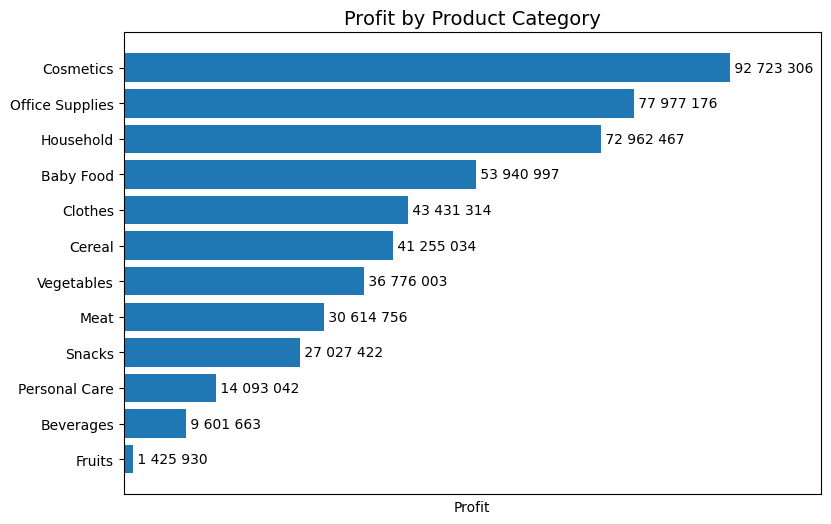

In [ ]:
plt.figure(figsize=(9, 6))
bars = plt.barh(by_item_type.index, by_item_type['total_profit'])
plt.xlabel("Profit")
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {bar.get_width():,.0f}".replace(",", " "),
        ha="left",
        va="center",
        color="black",
        fontsize=10,
    )
max_profit = by_item_type['total_profit'].max()
xlim_upper = max_profit * 1.15
plt.xlim(0, xlim_upper)
plt.xticks([])
plt.title("Profit by Product Category", fontsize=14)
plt.show()

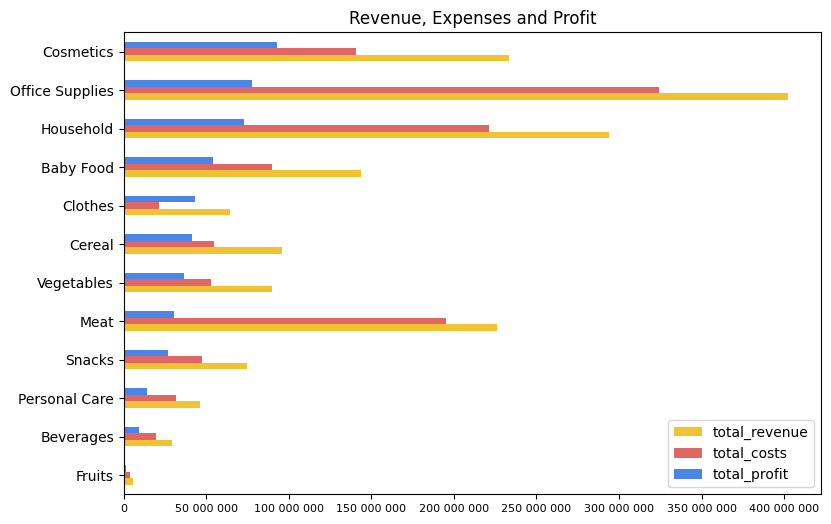

In [ ]:
by_item_type[['total_revenue', 'total_costs', 'total_profit']].plot(
    kind='barh',
    figsize=(9, 6),
    color=['#f1c232', '#e06666', '#4a86e8']
)

plt.title("Revenue, Expenses and Profit")
plt.ylabel("")
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", " ")))
plt.xticks(fontsize=8)
plt.show()

In [ ]:
by_country = df[df["country"] != "Unknown"]
by_country = by_country.groupby("country")[["total_revenue", "total_costs", "total_profit", "units_sold"]].sum().sort_values(by="total_profit", ascending=False)
by_country = by_country.head(7)

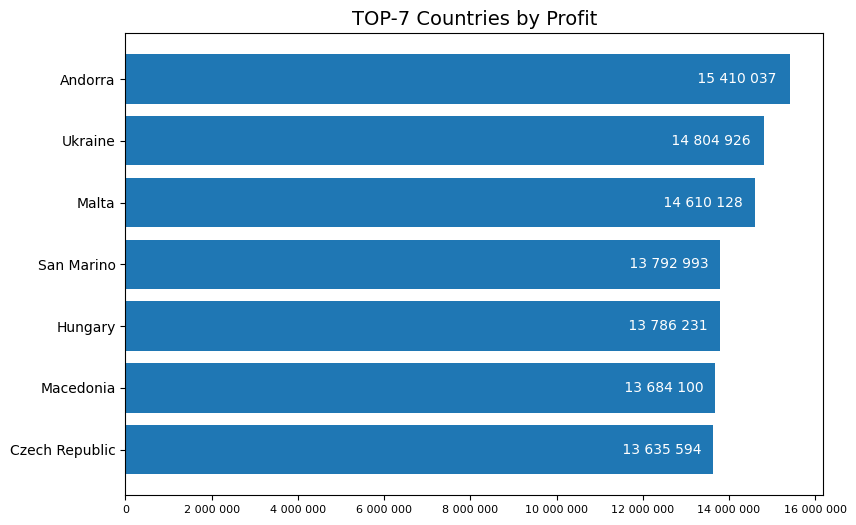

In [ ]:
by_country = by_country.sort_values(by="total_profit", ascending=True)
plt.figure(figsize=(9, 6))
bars = plt.barh(by_country.index, by_country['total_profit'])
plt.title("TOP-7 Countries by Profit", fontsize=14)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", " ")))
plt.xticks(fontsize=8)
for bar in bars:
    plt.text(
        bar.get_width() * 0.98,
        bar.get_y() + bar.get_height() / 2,
        f" {bar.get_width():,.0f}".replace(",", " "),
        ha="right",
        va="center",
        color="white",
        fontsize=10,
    )
plt.show()

In [ ]:
by_region = df[df["region"] != "Unknown"]
by_region = by_region.groupby("region")[["total_revenue", "total_costs", "total_profit", "units_sold"]].sum().sort_values(by="total_profit", ascending=False)
by_region

,total_revenue,total_costs,total_profit,units_sold
region,,,,
Europe,1 508 079 728,1 059 128 294,448 951 433,5770781
Asia,93 330 887,68 178 634,25 152 253,410427


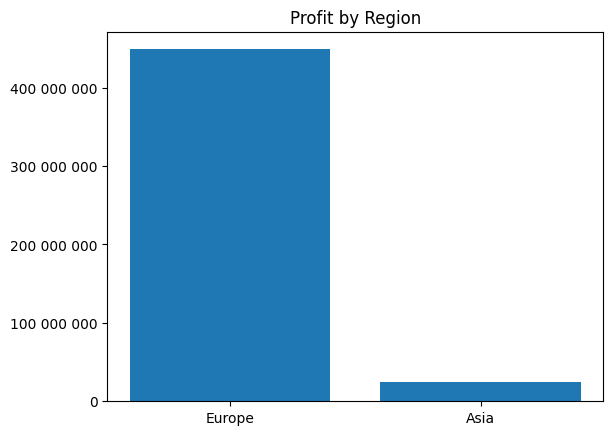

In [ ]:
plt.bar(by_region.index, by_region['total_profit'])
plt.title("Profit by Region")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " ")))
plt.show()

In [ ]:
df['sales_channel'] = df['sales_channel'].str.strip().str.title()
by_sales_channel = df.groupby("sales_channel")[["total_revenue", "total_costs", "total_profit", "units_sold"]].sum().sort_values(by="total_profit", ascending=False)
by_sales_channel

,total_revenue,total_costs,total_profit,units_sold
sales_channel,,,,
Offline,874 187 478,620 326 308,253 861 170,3329900
Online,830 368 784,582 400 844,247 967 940,3256161


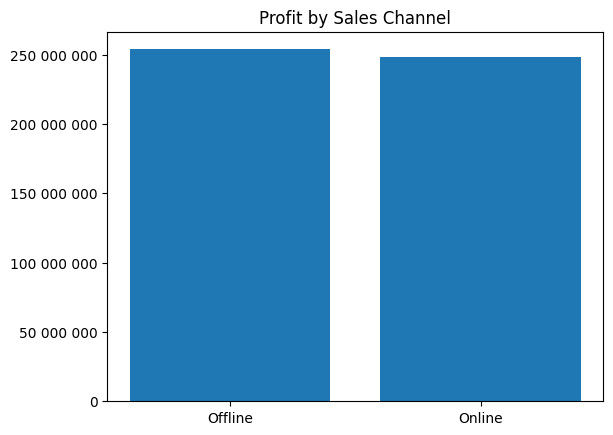

In [ ]:
plt.bar(by_sales_channel.index, by_sales_channel['total_profit'])
plt.title("Profit by Sales Channel")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " ")))
plt.show()

##4. Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:

- категорій товарів;
- країн;
- регіонів.

In [ ]:
df['order_to_ship'] = (df['ship_date'] - df['order_date']).dt.total_seconds() / 86400.0

In [ ]:
time_by_category = df.groupby('item_type')["order_to_ship"].median().sort_values()
time_by_category_display = time_by_category.map('{:.1f}'.format)
time_by_category_display

,order_to_ship
item_type,
Personal Care,20.0
Clothes,21.0
Vegetables,21.0
Beverages,23.0
Fruits,23.0
Household,24.0
Meat,25.0
Snacks,25.0
Office Supplies,27.0


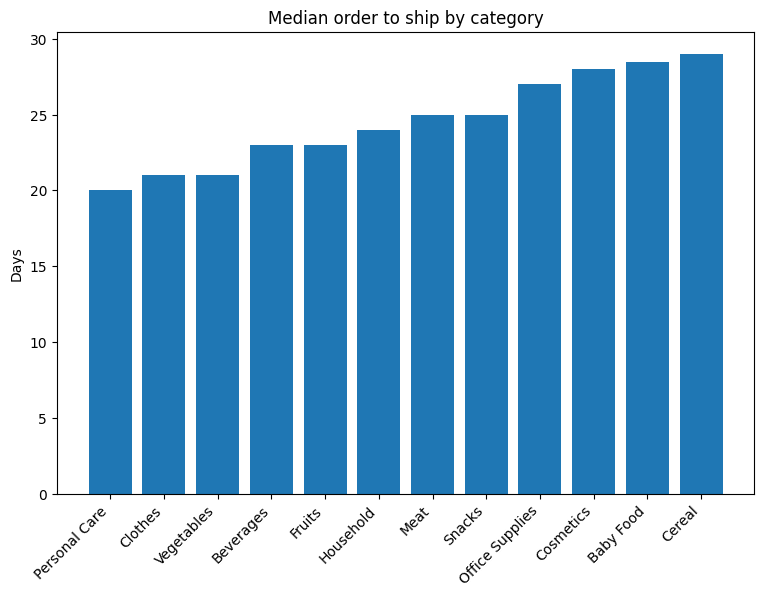

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(time_by_category.index, time_by_category.values)
plt.title("Median order to ship by category")
plt.ylabel("Days")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
time_by_country = df.groupby('country')["order_to_ship"].median().sort_values()
time_by_country_display = time_by_country.map('{:.1f}'.format)
time_by_country = time_by_country_display.head(7)
time_by_country = time_by_country.astype(float)

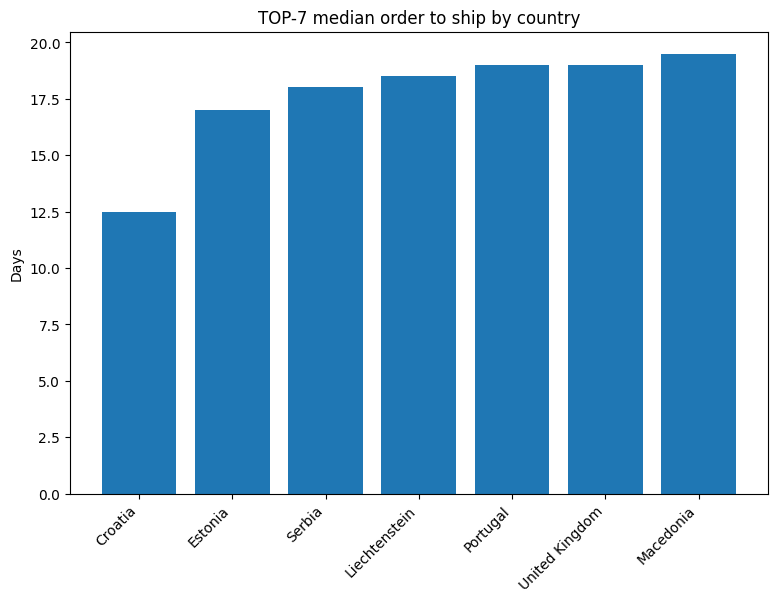

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(time_by_country.index, time_by_country.values)
plt.title("TOP-7 median order to ship by country")
plt.ylabel("Days")
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0)
plt.show()

In [ ]:
time_by_region = df[df['region'] != "Unknown"].groupby('region')["order_to_ship"].median().sort_values()
time_by_region

,order_to_ship
region,
Europe,25
Asia,26


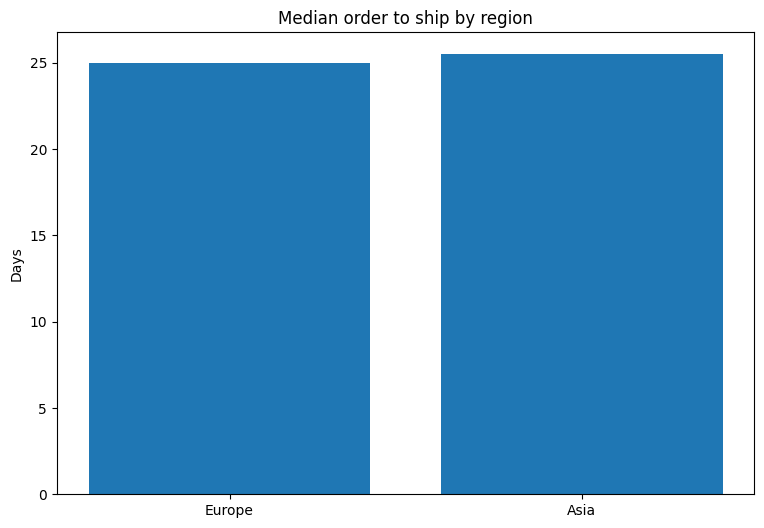

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(time_by_region.index, time_by_region.values)
plt.title("Median order to ship by region")
plt.ylabel("Days")
plt.show()

##5. Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.

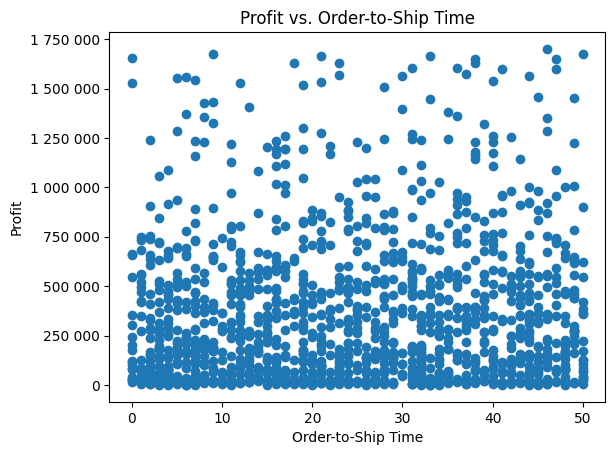

In [ ]:
plt.scatter(df['order_to_ship'], df['total_profit'])
plt.title("Profit vs. Order-to-Ship Time")
plt.xlabel("Order-to-Ship Time")
plt.ylabel("Profit")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " ")))
plt.show()

Явної залежності між прибутком та часом, який є необхідним на відвантаження товару не було зафіксовано

##6. Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,sales_channel,units_sold,unit_price,unit_cost,country,region,sub-region,item_type,total_revenue,total_costs,total_profit,order_to_ship
0,100640618,2014-10-08,2014-10-18,M,Online,650,206,117,Norway,Europe,Northern Europe,Cereal,133 705,76 122,57 584,10
1,100983083,2016-08-11,2016-08-11,C,Offline,1993,206,117,Serbia,Europe,Southern Europe,Cereal,409 960,233 400,176 560,0
2,101025998,2014-07-18,2014-08-11,M,Online,4693,668,503,Unknown,Unknown,Unknown,Household,3 136 191,2 358 420,777 771,24
3,102230632,2017-05-13,2017-06-13,L,Online,1171,109,36,Montenegro,Europe,Southern Europe,Clothes,127 967,41 969,85 998,31
4,103435266,2012-08-11,2012-09-18,H,Offline,7648,47,32,Serbia,Europe,Southern Europe,Beverages,362 898,243 130,119 768,38


In [ ]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

categories = [
    "Clothes",
    "Baby Food",
    "Household",
    "Office Supplies",
    "Cosmetics"
]

dynamics_by_category_year = pd.pivot_table(df[(df['year'] != 2017) & (df['item_type'].isin(categories))], index='year', columns='item_type', values='total_profit', aggfunc='sum')
dynamics_by_category_month = pd.pivot_table(df[(df['year'] != 2017) & (df['item_type'].isin(categories))], index='month', columns='item_type', values='total_profit', aggfunc='sum')

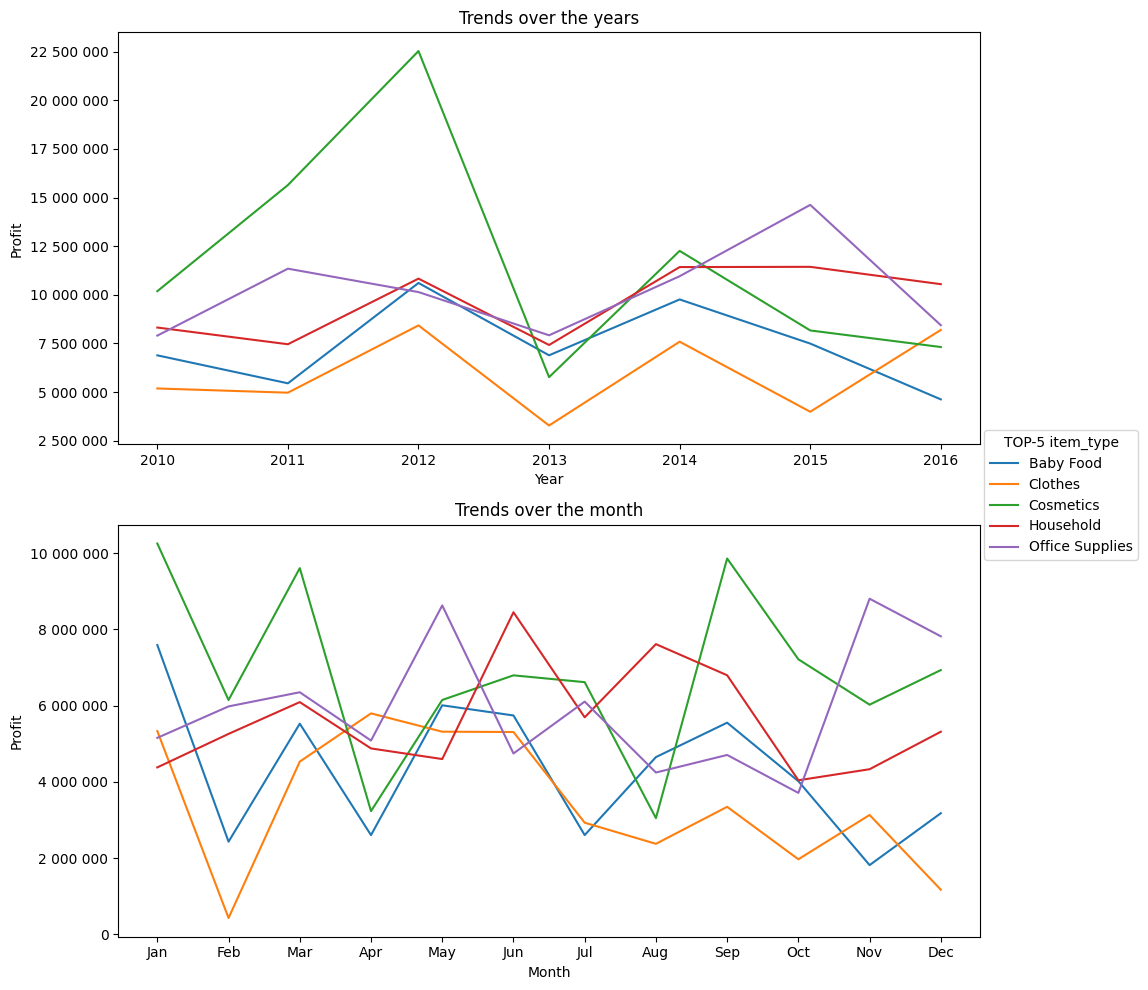

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

formatter = ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " "))

dynamics_by_category_year.plot(ax=ax[0], legend=False)
ax[0].set_title("Trends over the years")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Profit")
ax[0].yaxis.set_major_formatter(formatter)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

dynamics_by_category_month.plot(ax=ax[1], legend=False)
ax[1].set_title("Trends over the month")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Profit")
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(months)
ax[1].yaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), title="TOP-5 item_type")

plt.tight_layout()

plt.show()

In [ ]:
# TOP-7 Countries by Profit
countries = [
    "Andorra",
    "Ukraine",
    "Malta",
    "San Marino",
    "Hungary",
]

dynamics_by_country_year = pd.pivot_table(
    df[(df['country'].isin(countries)) & (df['year'] != 2017)],
    index='year',
    columns='country',
    values='total_profit',
    aggfunc='sum'
)

dynamics_by_country_month = pd.pivot_table(
    df[(df['country'].isin(countries)) & (df['year'] != 2017)],
    index='month',
    columns='country',
    values='total_profit',
    aggfunc='sum'
)

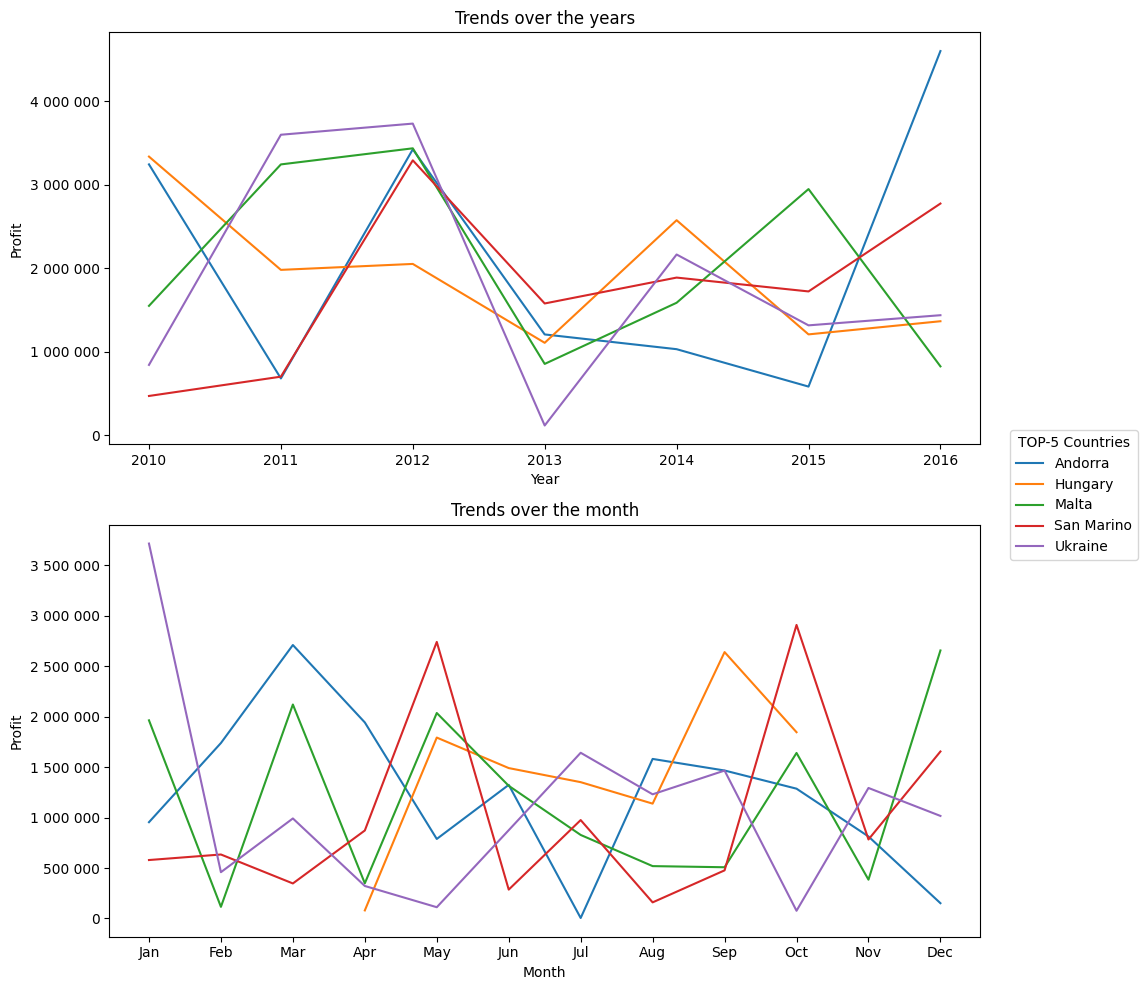

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

formatter = ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " "))

dynamics_by_country_year.plot(ax=ax[0], legend=False)
ax[0].set_title("Trends over the years")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Profit")
ax[0].yaxis.set_major_formatter(formatter)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

dynamics_by_country_month.plot(ax=ax[1], legend=False)
ax[1].set_title("Trends over the month")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Profit")
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(months)
ax[1].yaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), title="TOP-5 Countries")

plt.tight_layout()

plt.show()

In [ ]:
dynamics_by_region_year = pd.pivot_table(
    df[(df['region'] != 'Unknown') & (df['year'] != 2017)],
    index='year',
    columns='region',
    values='total_profit',
    aggfunc='sum'
)

dynamics_by_region_month = pd.pivot_table(
    df[(df['region'] != 'Unknown') & (df['year'] != 2017)],
    index='month',
    columns='region',
    values='total_profit',
    aggfunc='sum'
)

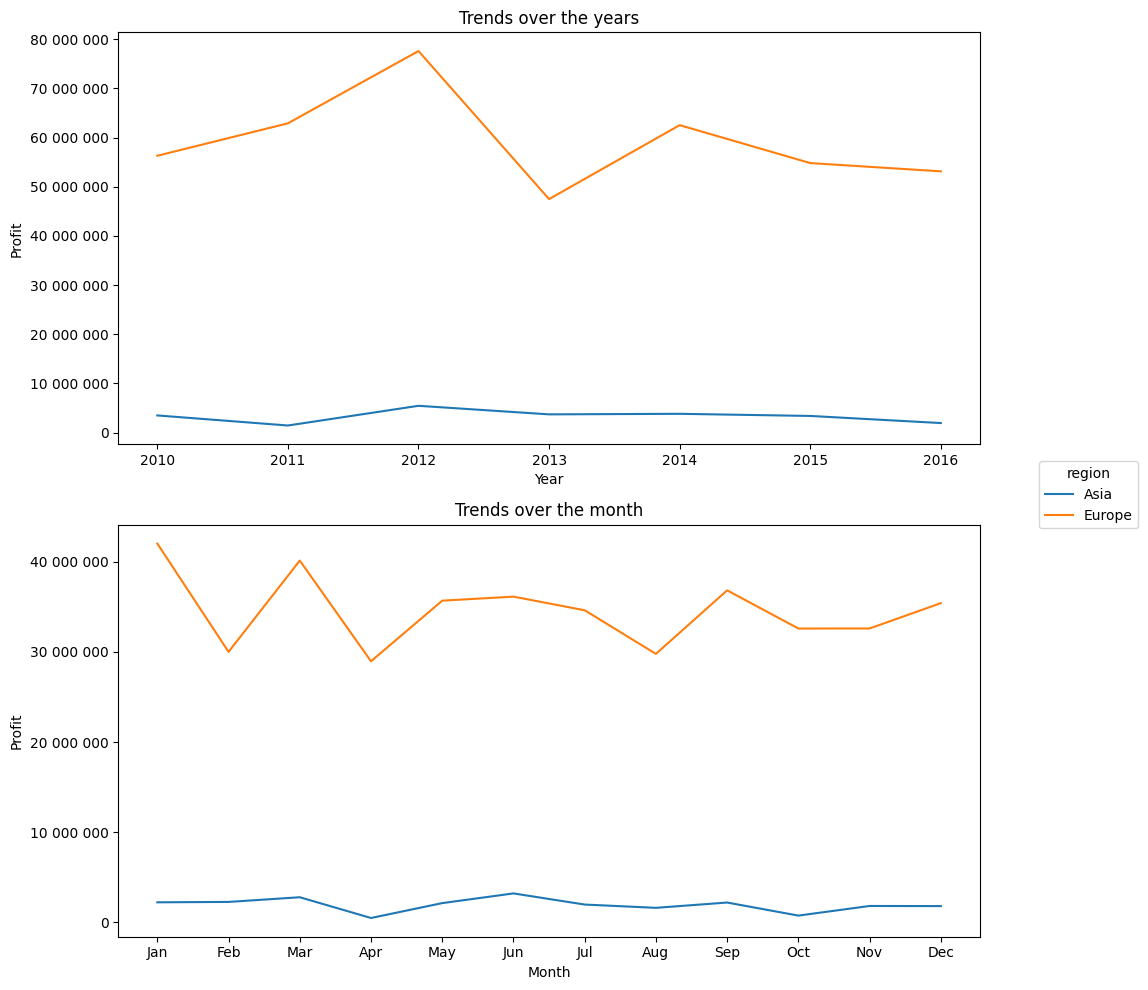

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

formatter = ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " "))

dynamics_by_region_year.plot(ax=ax[0], legend=False)
ax[0].set_title("Trends over the years")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Profit")
ax[0].yaxis.set_major_formatter(formatter)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

dynamics_by_region_month.plot(ax=ax[1], legend=False)
ax[1].set_title("Trends over the month")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Profit")
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(months)
ax[1].yaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), title="region")

plt.tight_layout()

plt.show()

- Під час дослідження динаміки було прийнято рішення не враховувати показники 2017 року, оскільки масив даних за цей період є неповним і обмежується сьомим місяцем.

##7. Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?

In [ ]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Створюємо колонку, одразу вказуючи, що це впорядкована категорія
df['day_of_week'] = pd.Categorical(
    df['order_date'].dt.day_name(),
    categories=days_order,
    ordered=True
)
products_by_day_of_week = pd.pivot_table(df, index='day_of_week', columns='item_type', values='total_profit', aggfunc='sum')
products_by_day_of_week

/tmp/ipykernel_497/3517380809.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  products_by_day_of_week = pd.pivot_table(df, index='day_of_week', columns='item_type', values='total_profit', aggfunc='sum')


item_type,Baby Food,Beverages,Cereal,Clothes,Cosmetics,Fruits,Household,Meat,Office Supplies,Personal Care,Snacks,Vegetables
day_of_week,,,,,,,,,,,,
Monday,5 858 292,1 599 246,3 691 900,5 001 925,9 717 247,284 602,17 870 500,5 742 194,11 860 051,1 789 860,5 950 488,6 541 657
Tuesday,8 190 854,1 256 997,5 146 902,9 124 332,14 154 583,103 124,3 393 156,5 224 591,9 654 716,1 909 823,3 840 336,3 915 007
Wednesday,7 787 187,1 183 959,5 157 444,3 197 431,11 929 221,206 759,15 837 159,5 104 013,11 817 505,1 846 321,2 228 373,6 028 473
Thursday,7 068 429,1 339 525,5 162 494,6 490 260,12 283 742,135 382,7 743 900,3 764 732,10 152 394,2 397 490,2 449 043,5 338 273
Friday,7 585 306,1 057 050,5 549 012,4 499 963,24 607 126,105 886,10 803 773,3 064 490,13 368 360,1 772 569,3 029 281,3 791 714
Saturday,8 467 601,1 607 186,8 528 471,7 408 187,11 316 503,263 020,9 417 607,4 537 676,8 202 589,2 275 949,5 446 950,3 964 122
Sunday,8 983 328,1 557 700,8 018 812,7 709 217,8 714 886,327 158,7 896 372,3 177 060,12 921 561,2 101 030,4 082 952,7 196 757


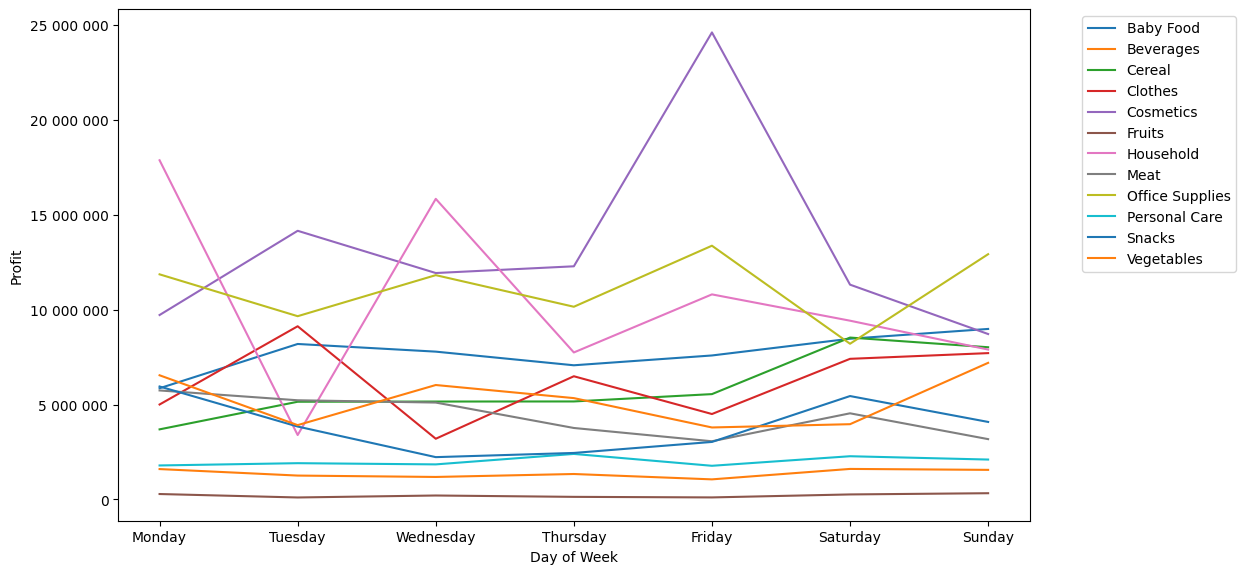

In [ ]:
products_by_day_of_week.plot(figsize=(12, 6))

plt.xlabel("Day of Week")
plt.ylabel("Profit")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " ")))

plt.show()

In [ ]:
day_of_week_by_profit = df.groupby("day_of_week")["total_profit"].sum()
day_of_week_by_profit

/tmp/ipykernel_497/1805751632.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_of_week_by_profit = df.groupby("day_of_week")["total_profit"].sum()


,total_profit
day_of_week,
Monday,75 907 962
Tuesday,65 914 420
Wednesday,72 323 843
Thursday,64 325 663
Friday,79 234 529
Saturday,71 435 860
Sunday,72 686 833


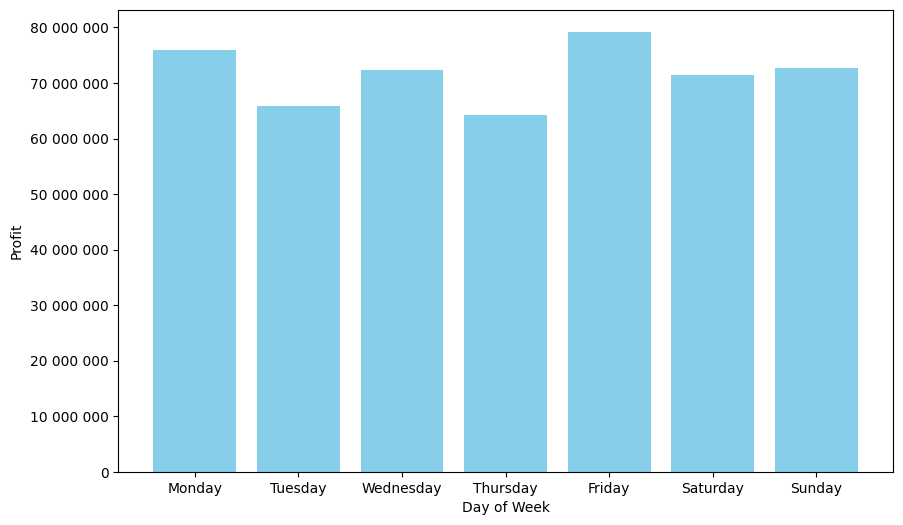

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(day_of_week_by_profit.index, day_of_week_by_profit.values, color="skyblue")
plt.xlabel("Day of Week")
plt.ylabel("Profit")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", " ")))
plt.show()

# Висновок

- Оцінка якості даних та загальні метрики діяльності

Проведено очищення вихідного масиву даних: ідентифіковано та усунено аномалії, заповнено пропуски, коректно розраховано показники Total Revenue, Total Cost та Total Profit для кожної транзакції.
Компанія реалізує продукцію у 45 країнах світу (Європи та Азії). Загальна кількість оброблених замовлень за досліджений період становить [Кількість] з них було зафіксовано 82 замовлення, які не мали заповнене поле Country Code.
Сумарний дохід (Total Revenue) склав 1 702 129 408 г.од. при цьому загальний чистий прибуток (Total Profit) зафіксовано на рівні 501 434 459 г.од.

- Аналіз продажів у розрізі категорій та географії

Категорії товарів: Найвищу популярність та найбільшу питому вагу в структурі загального прибутку демонструє категорія Cosmetics, а з точки зору дохід/витрати Clothes (дохід у 3 рази більший від витрат), а Cosmetics лише +66% від витрат. Найменш рентабельною виявилася категорія Fruits, але з точки зору дохід/витрати гірший відсоток має категорія  Meat , яка дає +16% від витрат в той час як Fruits +35% .
Географія: Лідером за обсягом збуту та згенерованого прибутку є регіон Європа, зокрема субрегіон Південна Європа. Найбільший прибуток у розрізі окремих країн зафіксований у Андорри.
Канали збуту: Розподіл прибутку між офлайн- та онлайн-продажами становить 50,5% та 49,5% відповідно.

- Часові тренди та логістичні показники

Найбільший прибуток було отримано за Січень. Найбільш прибутковим днем тижня для оформлення замовлень є п’ятниця.
Час відвантаження: Медіанний інтервал між датою замовлення та датою відвантаження становить 25 днів. Найбільший показник медіанної затримки серед країн зафіксовані в Угорщини, серед субрегіонів у Східній Європі, а серед категорії товарів у Cereal.
Кореляція: Аналіз графіка демонструє дуже слабку позитивну кореляцію між часом відвантаження та медіанним прибутком. Незважаючи на те, що лінія тренду має незначний висхідний нахил, висока дисперсія даних вказує на відсутність надійної закономірності. Отже, збільшення інтервалу між замовленням та відвантаженням не є гарантією зростання прибутку.

- Загальний висновок

Найприбутковіші товари (Група А): Cosmetics є абсолютним лідером за загальним прибутком, проте Clothes демонструє найкращу рентабельність інвестицій (ROI) — дохід втричі перевищує витрати.
Категорії Meat та Fruits загалом за всі роки є найменш ефективними. М'ясо має найнижчу націнку (+16% до витрат), а фрукти генерують найменше прибутку в абсолютному вимірі.
Основний ринок — Європа (зокрема, Південна Європа), а країна-лідер за прибутком — Андорра.
Медіанний час відвантаження становить аж 25 днів. Найбільші проблеми з логістикою спостерігаються в Східній Європі (зокрема, в Угорщині) та для категорії Cereal. При цьому тривалий час очікування не призводить до збільшення прибутку з замовлення.
Пік прибутковості припадає на січень, а найактивніший день тижня — п'ятниця.

